In [2]:
import numpy as np
import pandas as pd


In [3]:
final_df=pd.read_csv('final.csv')

In [4]:
final_df.head()
final_df.describe()

c:\Users\ramte\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,match_id,runs_left,balls_left,wickets_left,total_runs_x,crr,rrr,result
count,1.117210e+05,111721.000000,111721.000000,111721.000000,111721.000000,111721.000000,1.117050e+05,111721.000000
mean,9.226578e+05,94.768719,62.487402,7.494285,168.742170,7.587475,NaN,0.512903
std,3.763858e+05,51.081266,33.465263,2.173986,30.689233,2.341020,NaN,0.499836
min,3.359820e+05,-5.000000,-3.000000,0.000000,62.000000,0.000000,-inf,0.000000
25%,5.483430e+05,55.000000,34.000000,6.000000,149.000000,6.391304,7.348315e+00,0.000000
50%,1.082600e+06,94.000000,63.000000,8.000000,168.000000,7.611940,9.109091e+00,1.000000
75%,1.254095e+06,133.000000,91.000000,9.000000,188.000000,8.848485,1.136842e+01,1.000000
max,1.426312e+06,287.000000,119.000000,10.000000,287.000000,36.000000,inf,1.000000


In [5]:
final_df.head()
final_df.dropna(inplace=True)
final_df=final_df[final_df['balls_left']!=0]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [8]:
num=x.select_dtypes('number').columns
num
cat=x.drop(columns=num).columns

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler

trf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'),cat),
         ('num',MinMaxScaler(),num)
    ],
    remainder='passthrough'
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [11]:
pipe=Pipeline([
    ('step1',trf),
    ('step2',LogisticRegression(solver='liblinear')),
] )

In [12]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('step1', ...), ('step2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [13]:
y_pred=pipe.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,log_loss

In [15]:
accuracy_score(y_test,y_pred)

0.8090559589918838

In [16]:
from sklearn.model_selection import GroupShuffleSplit

X = final_df.drop(columns=['result', 'match_id'])
y = final_df['result']
groups = final_df['match_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler

num=X.select_dtypes('number').columns
num
cat=X.drop(columns=num).columns

trf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'),cat),
         ('num',MinMaxScaler(),num)
    ],
    remainder='passthrough'
)

In [18]:
from sklearn.ensemble import  (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


l=[]
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
  
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
}


for i,j in models.items():

    pipeline=Pipeline([
        ('1',trf),
        ('2',j)
    ])

    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    a=accuracy_score(y_pred,y_test)
    b=precision_score(y_pred,y_test)
    c=recall_score(y_pred,y_test)
    d=f1_score(y_pred,y_test)

    y_prob = pipeline.predict_proba(X_test)

    loss = log_loss(y_test, y_prob)
    dict={
        "Model":i,
        "accuracy":a,
        "precision_score":b,
        "recall_score":c,
        "f1_score":d,
        "Log Loss":loss
    }
    l.append(dict)
df=pd.DataFrame(l)

In [19]:
df.sort_values(['Log Loss'])

,Model,accuracy,precision_score,recall_score,f1_score,Log Loss
5,Gradient Boosting,0.756101,0.726579,0.843366,0.780629,0.499761
3,Random Forest,0.752649,0.717589,0.844896,0.776056,0.509829
0,Logistic Regression,0.742245,0.724412,0.822832,0.770492,0.567908
6,AdaBoost,0.767368,0.756442,0.838271,0.795257,0.577111
7,Extra Trees,0.691518,0.657141,0.790994,0.717881,0.589348
4,Naive Bayes,0.570408,0.832143,0.601451,0.698235,8.473270
2,Decision Tree,0.705327,0.691900,0.788780,0.737171,10.617711
1,KNN,0.590257,0.538252,0.705864,0.610767,13.733859


In [20]:
import pickle

pipeline=Pipeline([
    ('1',trf),
    ('2',GradientBoostingClassifier())
])
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)

print(y_pred[:10])



[1 1 0 0 1 1 0 1 1 0]


In [21]:
print(pipeline.predict_proba(X_test[:5]))

[[0.45482692 0.54517308]
 [0.13630882 0.86369118]
 [0.69812206 0.30187794]
 [0.59496697 0.40503303]
 [0.43344629 0.56655371]]


In [22]:
with open('pipe.pkl', 'wb') as f:
    pickle.dump(pipeline, f)


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score,log_loss
import matplotlib.pyplot as plt
y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8419309281069737


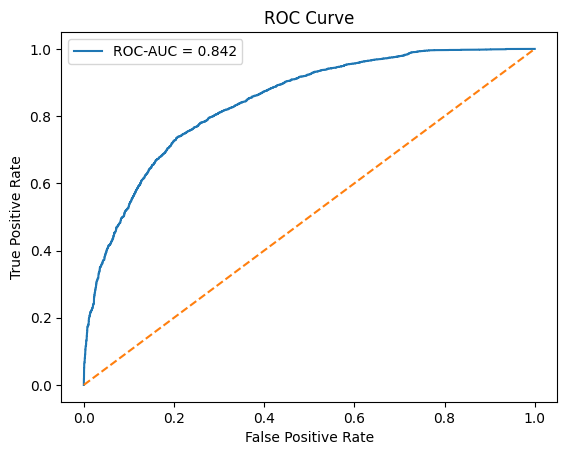

In [24]:
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
roc_auc_score(y_pred,y_test)

0.7534852868771368

In [26]:
y_prob = pipeline.predict_proba(X_test)
loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

Log Loss: 0.4996187435984501
